<a href="https://colab.research.google.com/github/ffigai/ETP-AgeAwareYTSafety/blob/main/etp_diagram.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!apt-get install graphviz -y
!pip install graphviz


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


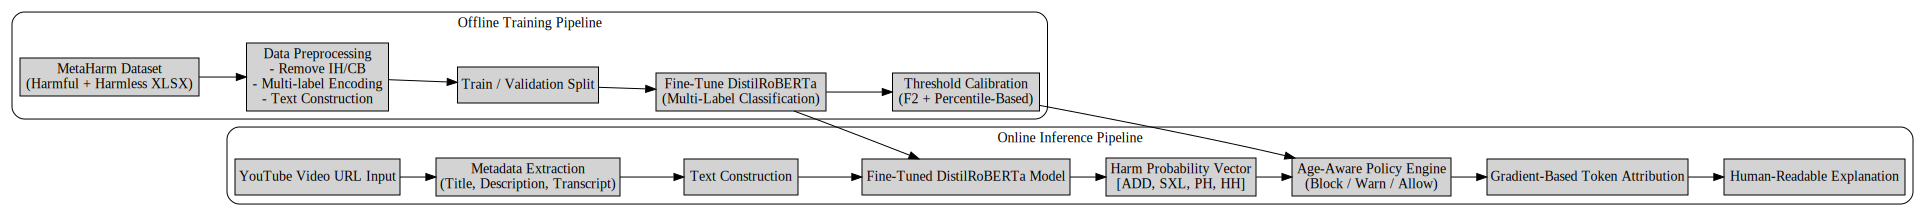

In [4]:
from graphviz import Digraph

dot = Digraph("AgeAwareYouTubeSafety", format="png")
dot.attr(rankdir="LR")  # Left to Right layout
dot.attr("node", shape="rectangle", style="filled", fillcolor="lightgray")

# =========================
# Offline Training Pipeline
# =========================

with dot.subgraph(name="cluster_training") as c:
    c.attr(label="Offline Training Pipeline", style="rounded", color="black")

    c.node("Dataset", "MetaHarm Dataset\n(Harmful + Harmless XLSX)")
    c.node("Preprocess", "Data Preprocessing\n- Remove IH/CB\n- Multi-label Encoding\n- Text Construction")
    c.node("Split", "Train / Validation Split")
    c.node("Train", "Fine-Tune DistilRoBERTa\n(Multi-Label Classification)")
    c.node("Threshold", "Threshold Calibration\n(F2 + Percentile-Based)")

    c.edges([
        ("Dataset", "Preprocess"),
        ("Preprocess", "Split"),
        ("Split", "Train"),
        ("Train", "Threshold")
    ])

# =========================
# Online Inference Pipeline
# =========================

with dot.subgraph(name="cluster_inference") as c:
    c.attr(label="Online Inference Pipeline", style="rounded", color="black")

    c.node("URL", "YouTube Video URL Input")
    c.node("Extract", "Metadata Extraction\n(Title, Description, Transcript)")
    c.node("TextBuild", "Text Construction")
    c.node("Model", "Fine-Tuned DistilRoBERTa Model")
    c.node("Probs", "Harm Probability Vector\n[ADD, SXL, PH, HH]")
    c.node("Policy", "Age-Aware Policy Engine\n(Block / Warn / Allow)")
    c.node("XAI", "Gradient-Based Token Attribution")
    c.node("Explain", "Human-Readable Explanation")

    c.edges([
        ("URL", "Extract"),
        ("Extract", "TextBuild"),
        ("TextBuild", "Model"),
        ("Model", "Probs"),
        ("Probs", "Policy"),
        ("Policy", "XAI"),
        ("XAI", "Explain")
    ])

# Connect training outputs to inference
dot.edge("Train", "Model")
dot.edge("Threshold", "Policy")

dot




In [5]:
dot.render("age_aware_youtube_system_architecture", format="png")


'age_aware_youtube_system_architecture.png'

In [6]:
from google.colab import files
files.download("age_aware_youtube_system_architecture.png")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>